# Import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

Even though our machine learning models will use a dataset with dummy variables, we will also load a version without dummies for comparison purposes.

In [2]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

Here is the primary dataset.

In [3]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


# Unadjusted Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = linreg.predict(X_test)
y_pred

array([32137.88905718, 12823.58246302, 38553.64281077, ...,
       10761.40286925,  4513.08001548, 20653.35597692])

In [6]:
# Create a new DataFrame showing the samples indices next to the non-dummy columns.
# This will allow us to compare results side-by-side with these categorial columns.
samples_no_dummies = no_dummies.loc[X_test.index]

# Build a new DataFrame compiling the results of the Linear Regression for each sample.
# We can also load categorical columns into this DataFrame.
linreg_init_results = pd.DataFrame()
linreg_init_results['make_model'] = samples_no_dummies['make_model']
linreg_init_results['Actual Price'] = y_test
linreg_init_results['Predicted Price'] = np.round(y_pred).astype(int)
linreg_init_results['Error'] = linreg_init_results['Predicted Price'] - linreg_init_results['Actual Price']
linreg_init_results['Squared Error'] = linreg_init_results['Error'] ** 2
linreg_init_results['Absolute Error'] = linreg_init_results['Error'].abs()
linreg_init_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14845,Renault Espace,34985.0,32138,-2847.0,8105409.0,2847.0
14120,Renault Clio,11280.0,12824,1544.0,2383936.0,1544.0
14860,Renault Espace,38875.0,38554,-321.0,103041.0,321.0
884,Audi A1,14500.0,15844,1344.0,1806336.0,1344.0
411,Audi A1,15900.0,17040,1140.0,1299600.0,1140.0
...,...,...,...,...,...,...
499,Audi A1,13700.0,13545,-155.0,24025.0,155.0
668,Audi A1,12451.0,13206,755.0,570025.0,755.0
8028,Opel Corsa,12990.0,10761,-2229.0,4968441.0,2229.0
8495,Opel Corsa,7650.0,4513,-3137.0,9840769.0,3137.0


In [7]:
print(f"Mean squared error: {linreg_init_results['Squared Error'].mean()}")
print(f"Mean absolute error: {linreg_init_results['Absolute Error'].mean()}")
print(f"Median squared error: {linreg_init_results['Absolute Error'].median()}")

Mean squared error: 5605251.23013245
Mean absolute error: 1658.15
Median squared error: 1197.5


Let's verify that the results calculated from our DataFrame are identical to the "out-of-the-box" metrics Scikit-learn provides.

In [8]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Median Absolute Error: {median_absolute_error(y_test, y_pred)}")

R2 Score: 0.9009513488653939
Mean Squared Error: 5605252.241853897
Mean Absolute Error: 1658.1499208874586
Median Absolute Error: 1197.4056613203138


In [9]:
linreg_init_results.nsmallest(10, 'Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
12143,Opel Insignia,49350.0,31338,-18012.0,324432144.0,18012.0
12150,Opel Insignia,44970.0,27418,-17552.0,308072704.0,17552.0
3402,Audi A3,56100.0,41518,-14582.0,212634724.0,14582.0
15051,Renault Espace,49690.0,35432,-14258.0,203290564.0,14258.0
15021,Renault Espace,47450.0,34481,-12969.0,168194961.0,12969.0
14988,Renault Espace,44500.0,32617,-11883.0,141205689.0,11883.0
15062,Renault Espace,47990.0,36251,-11739.0,137804121.0,11739.0
12416,Opel Insignia,39990.0,28264,-11726.0,137499076.0,11726.0
11890,Opel Insignia,36990.0,25292,-11698.0,136843204.0,11698.0
15033,Renault Espace,45990.0,34739,-11251.0,126585001.0,11251.0


In [10]:
linreg_init_results.nlargest(10, 'Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
10336,Opel Insignia,11600.0,24944,13344.0,178062336.0,13344.0
8471,Opel Corsa,10500.0,21969,11469.0,131537961.0,11469.0
3035,Audi A3,14250.0,24818,10568.0,111682624.0,10568.0
10400,Opel Insignia,8990.0,18954,9964.0,99281296.0,9964.0
10673,Opel Insignia,10500.0,18276,7776.0,60466176.0,7776.0
724,Audi A1,25900.0,33670,7770.0,60372900.0,7770.0
10381,Opel Insignia,10262.0,17507,7245.0,52490025.0,7245.0
10072,Opel Insignia,17999.0,25144,7145.0,51051025.0,7145.0
6137,Opel Astra,6950.0,13806,6856.0,47004736.0,6856.0
14611,Renault Espace,19900.0,26639,6739.0,45414121.0,6739.0


In [ ]:
# Plot scatter + regression line
plt.figure(figsize=(8,6))
plt.scatter(X_single, y, alpha=0.5, label="Data points")
plt.plot(x_range, y_pred_line, color="red", linewidth=2, label="Regression line")
plt.xlabel(feature)
plt.ylabel("Price")
plt.title(f"Linear Regression of Price vs {feature}")
plt.legend()
plt.show()

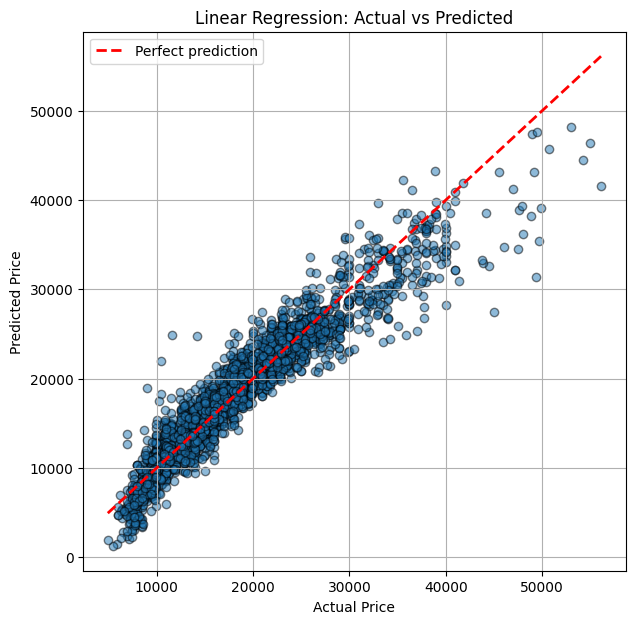

In [30]:
# Predictions on the test set
y_pred = linreg.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black', linewidths=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

# Linear Regression with K-Fold Cross Validation

Graph R2 score by number of folds

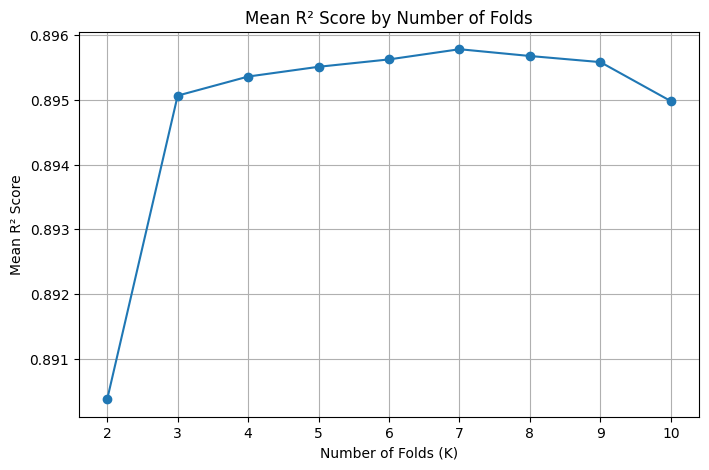

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

folds = range(2, 11)  # try folds from 2 to 10
mean_r2_scores = []

for k in folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(linreg, X, y, cv=kf, scoring='r2')
    mean_r2_scores.append(np.mean(scores))

# Plot
plt.figure(figsize=(8,5))
plt.plot(folds, mean_r2_scores, marker='o')
plt.title("Mean R² Score by Number of Folds")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Mean R² Score")
plt.grid(True)
#plt.xticks(np.arange(min(x), max(x) + 1, 1))
plt.show()

Let's re-run the linear regression with 7 folds.

In [14]:
# Define K-Fold
kf = KFold(n_splits=7, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(linreg, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.90033498 0.90567797 0.89138482 0.90330205 0.89108238 0.8910221
 0.8876413 ]
Mean R²: 0.8957779434041429
Standard deviation of R²: 0.006606923351592207


In [21]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(linreg, X, y, cv=kf)

# Build results dataframe
linreg_cv_results = pd.DataFrame()
linreg_cv_results['make_model'] = no_dummies['make_model']
linreg_cv_results['Actual Price'] = y
linreg_cv_results['Predicted Price'] = np.round(y_pred_all).astype(int)
linreg_cv_results['Error'] = linreg_cv_results['Predicted Price'] - linreg_cv_results['Actual Price']
linreg_cv_results['Squared Error'] = linreg_cv_results['Error'] ** 2
linreg_cv_results['Absolute Error'] = linreg_cv_results['Error'].abs()
linreg_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,14401,-1369.0,1874161.0,1369.0
1,Audi A1,14500.0,19563,5063.0,25633969.0,5063.0
2,Audi A1,14640.0,15574,934.0,872356.0,934.0
3,Audi A1,14500.0,12905,-1595.0,2544025.0,1595.0
4,Audi A1,16790.0,16033,-757.0,573049.0,757.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,35565,-4385.0,19228225.0,4385.0
15096,Renault Espace,39885.0,39377,-508.0,258064.0,508.0
15097,Renault Espace,39875.0,38777,-1098.0,1205604.0,1098.0
15098,Renault Espace,39700.0,33682,-6018.0,36216324.0,6018.0


# Ridge

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict, KFold

# Define Ridge regression (you can tune alpha later)
ridge = Ridge(alpha=1.0, random_state=42)

# Cross-validated predictions (7-fold)
kf = KFold(n_splits=7, shuffle=True, random_state=42)
y_pred_ridge = cross_val_predict(ridge, X, y, cv=kf)

# Build results dataframe
ridge_cv_results = pd.DataFrame(index=scout_car.index)
ridge_cv_results['make_model'] = no_dummies['make_model']
ridge_cv_results['Actual Price'] = y
ridge_cv_results['Predicted Price'] = np.round(y_pred_ridge).astype(int)
ridge_cv_results['Error'] = ridge_cv_results['Predicted Price'] - ridge_cv_results['Actual Price']
ridge_cv_results['Squared Error'] = ridge_cv_results['Error'] ** 2
ridge_cv_results['Absolute Error'] = ridge_cv_results['Error'].abs()
ridge_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,14237,-1533.0,2350089.0,1533.0
1,Audi A1,14500.0,19777,5277.0,27846729.0,5277.0
2,Audi A1,14640.0,15415,775.0,600625.0,775.0
3,Audi A1,14500.0,13131,-1369.0,1874161.0,1369.0
4,Audi A1,16790.0,16021,-769.0,591361.0,769.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,35556,-4394.0,19307236.0,4394.0
15096,Renault Espace,39885.0,39334,-551.0,303601.0,551.0
15097,Renault Espace,39875.0,39419,-456.0,207936.0,456.0
15098,Renault Espace,39700.0,33767,-5933.0,35200489.0,5933.0


# Lasso

In [25]:
from sklearn.linear_model import Lasso

# Define Lasso regression (alpha controls regularization strength)
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)

# Cross-validated predictions (7-fold)
kf = KFold(n_splits=7, shuffle=True, random_state=42)
y_pred_lasso = cross_val_predict(lasso, X, y, cv=kf)

# Build results dataframe
lasso_cv_results = pd.DataFrame(index=scout_car.index)
lasso_cv_results['make_model'] = no_dummies['make_model']
lasso_cv_results['Actual Price'] = y
lasso_cv_results['Predicted Price'] = np.round(y_pred_lasso).astype(int)
lasso_cv_results['Error'] = lasso_cv_results['Predicted Price'] - lasso_cv_results['Actual Price']
lasso_cv_results['Squared Error'] = lasso_cv_results['Error'] ** 2
lasso_cv_results['Absolute Error'] = lasso_cv_results['Error'].abs()
lasso_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,14252,-1518.0,2304324.0,1518.0
1,Audi A1,14500.0,19781,5281.0,27888961.0,5281.0
2,Audi A1,14640.0,15418,778.0,605284.0,778.0
3,Audi A1,14500.0,13169,-1331.0,1771561.0,1331.0
4,Audi A1,16790.0,16037,-753.0,567009.0,753.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,35558,-4392.0,19289664.0,4392.0
15096,Renault Espace,39885.0,39332,-553.0,305809.0,553.0
15097,Renault Espace,39875.0,39395,-480.0,230400.0,480.0
15098,Renault Espace,39700.0,33772,-5928.0,35141184.0,5928.0


# Lasso and Ridge

# Comparing Results

In [32]:
# Start with make_model + Actual Price (take from linreg to avoid duplicates)
combined_results = pd.DataFrame({
    "make_model": linreg_cv_results["make_model"],
    "Actual Price": linreg_cv_results["Actual Price"],
})

# Add model-specific results
combined_results["LinReg_Predicted Price"] = linreg_cv_results["Predicted Price"]
combined_results["LinReg_Error"] = linreg_cv_results["Error"]
combined_results["LinReg_Squared Error"] = linreg_cv_results["Squared Error"]
combined_results["LinReg_Absolute Error"] = linreg_cv_results["Absolute Error"]

combined_results["Ridge_Predicted Price"] = ridge_cv_results["Predicted Price"]
combined_results["Ridge_Error"] = ridge_cv_results["Error"]
combined_results["Ridge_Squared Error"] = ridge_cv_results["Squared Error"]
combined_results["Ridge_Absolute Error"] = ridge_cv_results["Absolute Error"]

combined_results["Lasso_Predicted Price"] = lasso_cv_results["Predicted Price"]
combined_results["Lasso_Error"] = lasso_cv_results["Error"]
combined_results["Lasso_Squared Error"] = lasso_cv_results["Squared Error"]
combined_results["Lasso_Absolute Error"] = lasso_cv_results["Absolute Error"]
combined_results

,make_model,Actual Price,LinReg_Predicted Price,LinReg_Error,LinReg_Squared Error,LinReg_Absolute Error,Ridge_Predicted Price,Ridge_Error,Ridge_Squared Error,Ridge_Absolute Error,Lasso_Predicted Price,Lasso_Error,Lasso_Squared Error,Lasso_Absolute Error
0,Audi A1,15770.0,14401,-1369.0,1874161.0,1369.0,14237,-1533.0,2350089.0,1533.0,14252,-1518.0,2304324.0,1518.0
1,Audi A1,14500.0,19563,5063.0,25633969.0,5063.0,19777,5277.0,27846729.0,5277.0,19781,5281.0,27888961.0,5281.0
2,Audi A1,14640.0,15574,934.0,872356.0,934.0,15415,775.0,600625.0,775.0,15418,778.0,605284.0,778.0
3,Audi A1,14500.0,12905,-1595.0,2544025.0,1595.0,13131,-1369.0,1874161.0,1369.0,13169,-1331.0,1771561.0,1331.0
4,Audi A1,16790.0,16033,-757.0,573049.0,757.0,16021,-769.0,591361.0,769.0,16037,-753.0,567009.0,753.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,Renault Espace,39950.0,35565,-4385.0,19228225.0,4385.0,35556,-4394.0,19307236.0,4394.0,35558,-4392.0,19289664.0,4392.0
15096,Renault Espace,39885.0,39377,-508.0,258064.0,508.0,39334,-551.0,303601.0,551.0,39332,-553.0,305809.0,553.0
15097,Renault Espace,39875.0,38777,-1098.0,1205604.0,1098.0,39419,-456.0,207936.0,456.0,39395,-480.0,230400.0,480.0
15098,Renault Espace,39700.0,33682,-6018.0,36216324.0,6018.0,33767,-5933.0,35200489.0,5933.0,33772,-5928.0,35141184.0,5928.0


In [35]:
comparisons_df = pd.DataFrame()
comparisons_df['3MA Error'] = (combined_results["LinReg_Error"] + combined_results["Ridge_Error"] + combined_results["Lasso_Error"]) / 3
comparisons_df['3MA Squared Error'] = (combined_results["LinReg_Squared Error"] + combined_results["Ridge_Squared Error"] + combined_results["Lasso_Squared Error"]) / 3
comparisons_df['3MA Absolute Error'] = (combined_results["LinReg_Absolute Error"] + combined_results["Ridge_Squared Error"] + combined_results["Lasso_Absolute Error"]) / 3
comparisons_df

,3MA Error,3MA Squared Error,3MA Absolute Error
0,-1473.333333,2.176191e+06,7.843253e+05
1,5207.000000,2.712322e+07,9.285691e+06
2,829.000000,6.927550e+05,2.007790e+05
3,-1431.666667,2.063249e+06,6.256957e+05
4,-759.666667,5.771397e+05,1.976237e+05
...,...,...,...
15095,-4390.333333,1.927504e+07,6.438671e+06
15096,-537.333333,2.891580e+05,1.015540e+05
15097,-678.000000,5.479800e+05,6.983800e+04
15098,-5959.666667,3.551933e+07,1.173748e+07
